# SwiftCNV on Ovarian cancer dataset

This tutorial demonstrates how to run **SwiftCNV** from a Jupyter notebook and perform downstream analysis using the resulting copy number variation (CNV) matrix. It also shows how to load the results generated with the command-line interface into an `AnnData` object.

## Load packages

In [1]:
import sys
import scanpy as sc
import matplotlib.pyplot as plt
import warnings
import logging
import requests

import swiftcnv as cnv
from swiftcnv.data import Qian2020_Ovarian

logging.basicConfig(level=logging.INFO, datefmt='%H:%M:%S',
                    format='%(asctime)s [%(levelname)s]: %(message)s')
warnings.simplefilter('ignore')

sc.settings.set_figure_params(figsize=(5, 5))

In [2]:
gtf_filename = 'gencode.v44.basic.annotation.gtf.gz'
output_dir = 'example_output'

## Load example dataset

In [3]:
adata = Qian2020_Ovarian()
adata

AnnData object with n_obs × n_vars = 4000 × 12000
    obs: 'sample', 'cell_type'
    obsm: 'X_umap'
    layers: None (.X)

The obtained anndata object consist of raw transcript counts for 4k cells with 12k genes.

We can first inspect the UMAP plot based on gene expression:

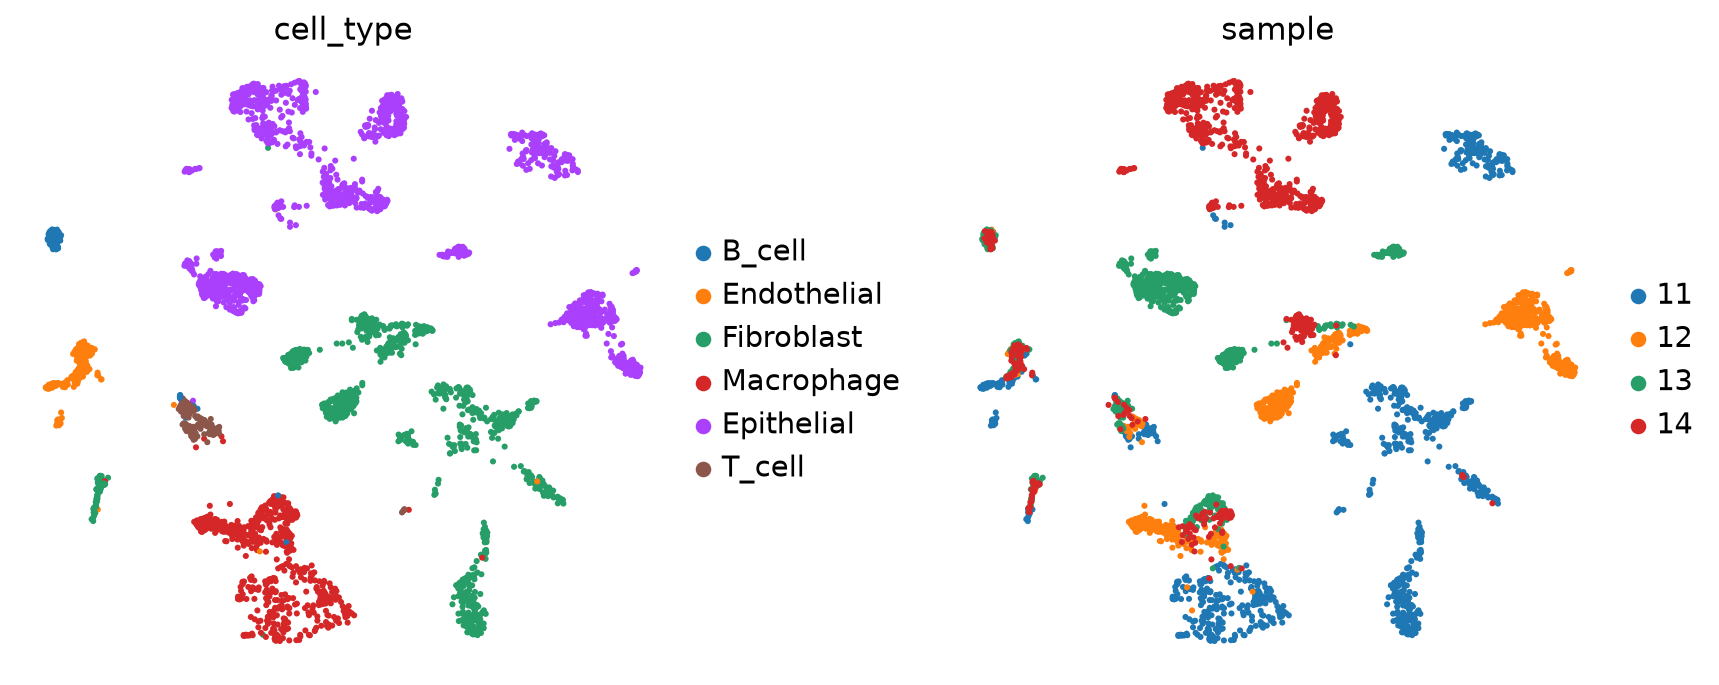

In [4]:
sc.pl.umap(adata, color=['cell_type', 'sample'], wspace=0.3, frameon=False)

The dataset contains the representative cells from the tumor microenvironment as well as several epithelial cell for 4 different patients.

## Get Gene Annotations

To run SwiftCNV a GTF file with gene coordinates is needed. If not available, it can be downloaded from [Gencode](https://www.gencodegenes.org/human/) database using one of the latest releases:

In [5]:
gtf_url = 'https://ftp.ebi.ac.uk/pub/databases/gencode/Gencode_human/release_44/gencode.v44.basic.annotation.gtf.gz'

print('Downloading file...')
with requests.get(gtf_url, stream=True) as r:
    r.raise_for_status()
    with open(gtf_filename, 'wb') as f:
        for chunk in r.iter_content(chunk_size=8192): 
            f.write(chunk)

print('Download finished!')

Download finished!


## Running SwiftCNV

We will use T cells, Macrophages and fibroblasts as reference cells. The `exclude_immune` parameter excludes immune-associated genes, such as HLA and immunoglobulins, that could confound CNV inference. We use `read_X` to specify that raw counts should be taken from the main matrix. The `cutoff` parameter filters out genes whose average expression across the reference cells falls below the specified value. When running the analysis from a notebook the final CNV heatmap and the HMM analysis are disabled to reduce memory usage.

In [ ]:
adata, cnv_states, subclusters_df = cnv.run_from_adata(
    adata,
    output_dir=output_dir,
    gtf_file=gtf_filename,
    reference_col='cell_type',
    reference_vals=['T_cell', 'Macrophage', 'Fibroblast'],
    sample_col='sample',
    exclude_immune=True,
    read_X=True,
    plot=True,
    run_hmm=True,
    hmm_by='subcluster',
)

16:21:07 [INFO]: [1/6] Using pre-loaded adata...
16:21:07 [INFO]:     counts shape (cells x genes): (4000, 12000)
16:21:07 [INFO]: [2/6] Getting reference cells...
16:21:07 [INFO]:     Getting reference cells from adata.obs["cell_type"] (values=['T_cell', 'Macrophage', 'Fibroblasts'])
16:21:07 [INFO]:     Total cells: 4000
16:21:07 [INFO]:     Reference cells: 926
16:21:07 [INFO]:     Observation cells: 3074
16:21:07 [INFO]:     Using sample_col: "sample" with 4 samples
16:21:07 [INFO]: [3/6] Getting gene order...
16:21:07 [INFO]:     Getting gene_order from GTF: gencode.v44.basic.annotation.gtf.gz
16:21:10 [INFO]:     Gene order from GTF: 57148 genes loaded.
16:21:10 [INFO]:     Subsetting to common genes: 11389
16:21:10 [INFO]: [4/6] Running SwiftCNV...
16:21:11 [INFO]:     SwiftCNV object created: 4000 cells x 11389 genes (926 reference + 3074 observation cells)
16:21:11 [INFO]: === Starting SwiftCNV pipeline ===
16:21:11 [INFO]:     1: Gene filtering (min_cells=3): from 11389 to 11

The resulting cnv matrix with the genes considered for the analysis has been added to the obsm slot.

In [7]:
print(adata)
print(adata.obsm['cnv_mat'].shape)

AnnData object with n_obs × n_vars = 4000 × 12000
    obs: 'sample', 'cell_type', 'reference'
    var: 'chr', 'arm', 'chr_arm', 'start', 'end', 'has_cnv'
    uns: 'cell_type_colors', 'sample_colors'
    obsm: 'X_umap', 'cnv_mat'
    layers: None (.X)
(4000, 6393)


## Load SwiftCNV results from an output directory

If SwiftCNV was run from the command line, the output files are saved in the specified directory. These results can be loaded into an `AnnData` object using the `load_output` function by providing the path to the output directory.

In [8]:
cnv.load_output(output_dir, adata, inplace=True)

## Smoothing CNV matrix by chromosome arm

The CNV signal can be further smoothed by chromosome arms to reduce the noise. In this case, a new `cnv_mat_arms` is added to the obsm slot.

In [9]:
cnv.summarise_by_chr_arm(adata, key_obsm='cnv_mat', inplace=True)

With this matrix we can generate a UMAP base only on CNV values using the scanpy workflow.

In [10]:
sc.pp.neighbors(adata, use_rep='cnv_mat_arms', key_added='cnv_neighbors')
sc.tl.leiden(adata, neighbors_key='cnv_neighbors', key_added='cnv_leiden')
sc.tl.umap(adata, neighbors_key='cnv_neighbors', min_dist=0.5, spread=1, key_added='cnv_umap')

... storing 'chr' as categorical
... storing 'arm' as categorical
... storing 'chr_arm' as categorical


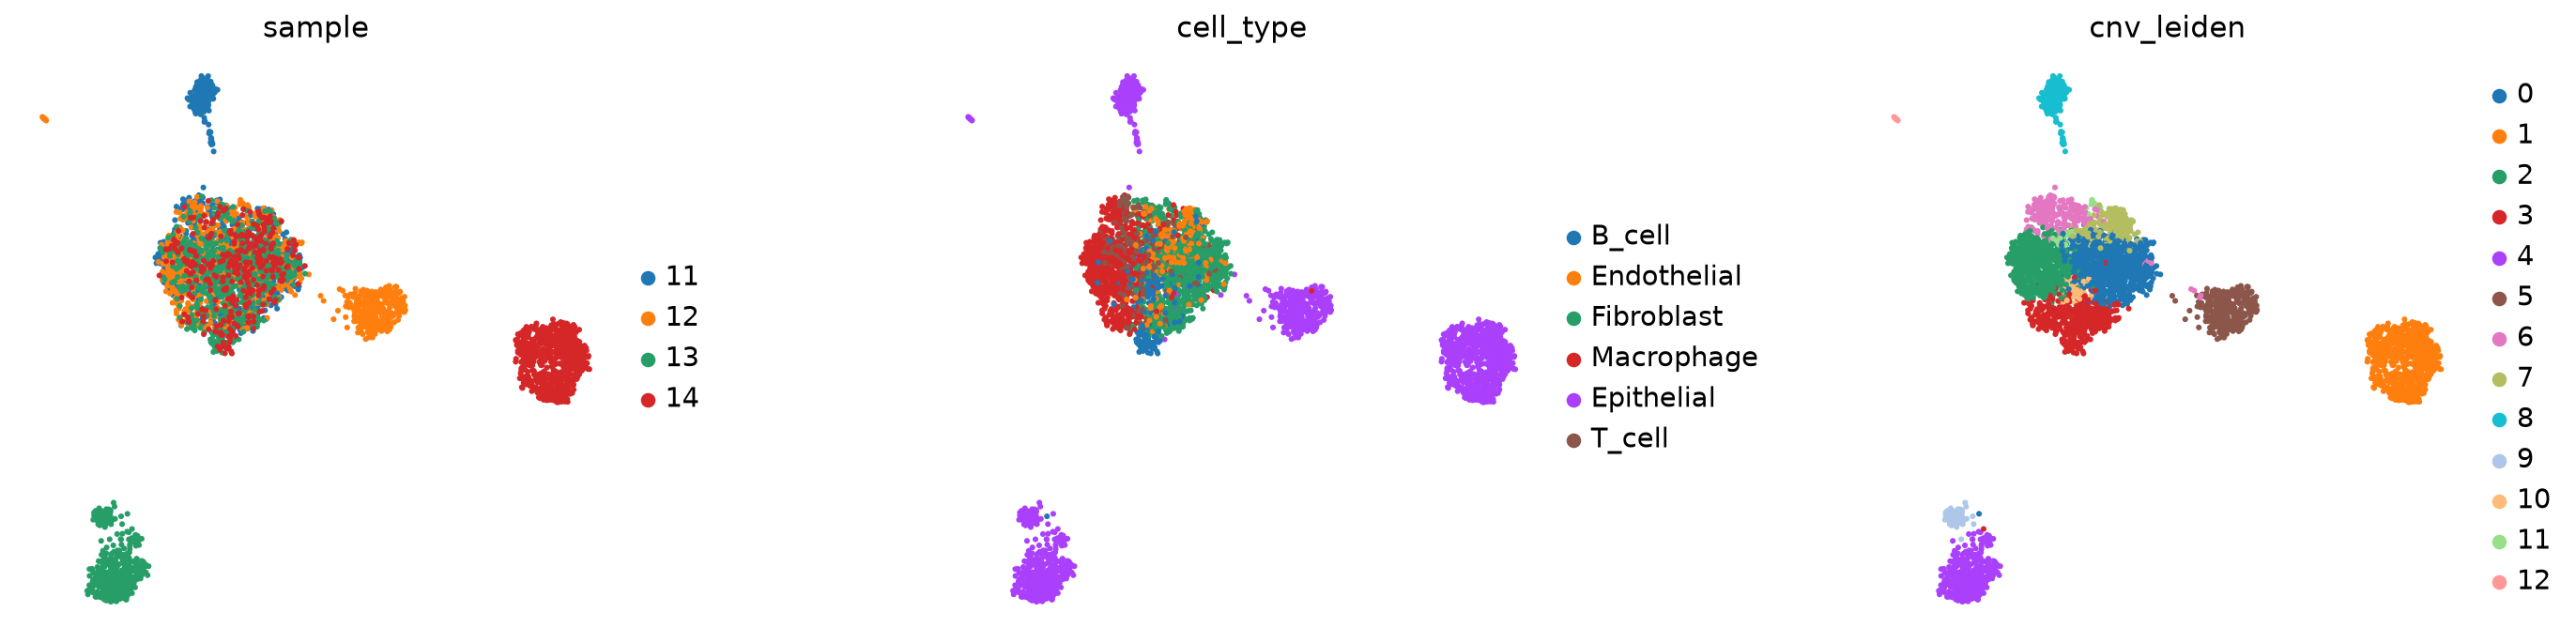

In [11]:
sc.pl.embedding(adata, basis='cnv_umap', color=['sample', 'cell_type', 'cnv_leiden'], wspace=0.4,frameon=False)

Additionally, a CNV score per cell can be obtained from the Mean Squared Error of the smoothed values.

In [12]:
cnv.cnv_score(adata, key_obsm='cnv_mat_arms', inplace=True)

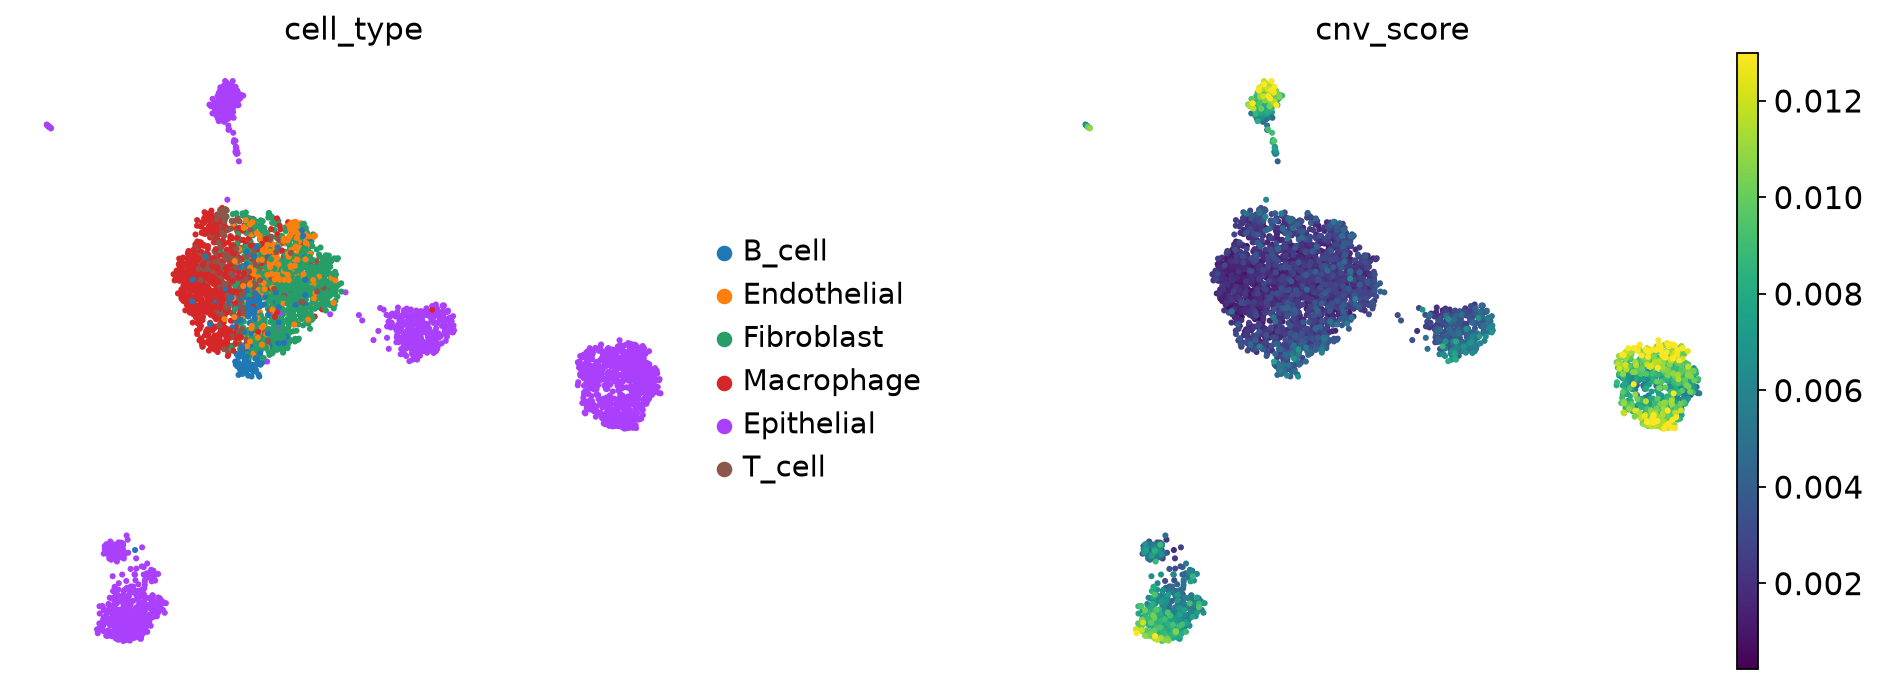

In [13]:
sc.pl.embedding(adata, basis='cnv_umap',color=['cell_type', 'cnv_score'], wspace=0.4, frameon=False, vmax='p99')